## 📦 Step 1: Install & Import Libraries

Before we do anything, we need to bring in all the tools we'll be using.
Think of this like gathering your supplies before starting a project.

- `pandas` & `numpy` → for loading and working with data
- `matplotlib` & `seaborn` → for making charts and graphs
- `nltk` → for text cleaning (removing stopwords etc.)
- `sklearn` → this is our main machine learning toolkit
- `joblib` → to save our trained model so we can reuse it later

We also download some NLTK data files that are needed for processing English text.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib


## 📂 Step 2: Load the Dataset

Here we load our Kaggle Twitter Sentiment dataset from the CSV file.

The dataset has **27,481 tweets** with columns like:
- `text` → the actual tweet
- `sentiment` → whether it's *positive*, *negative*, or *neutral*
- Plus extra info like country, age group, time of tweet etc.

We use `encoding='latin-1'` because the file has some special characters
that the default UTF-8 encoding can't read — a super common CSV gotcha!


In [ ]:
# Load the Kaggle Twitter Sentiment dataset
df = pd.read_csv('data.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Shape: (27481, 10)

Columns: ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


## 🔍 Step 3: Explore the Data (Basic EDA)

Before jumping into any modeling, we always explore our data first.
This tells us what we're working with and flags any obvious issues.

Key things we check:
- **Sentiment distribution** → are the classes balanced?
- **Null values** → any missing data we need to handle?
- **Data types** → are columns stored as the right types?

Spoiler: we have ~11k neutral, ~8.5k positive, and ~7.7k negative tweets.
Slightly imbalanced but not too bad.


In [ ]:
# Check data types, nulls, and sentiment distribution
print("Sentiment counts:")
print(df['sentiment'].value_counts())
print("\nNull values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)


Sentiment counts:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

Null values:
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

Data types:
textID               object
text                 object
selected_text        object
sentiment            object
Time of Tweet        object
Age of User          object
Country              object
Population -2020      int64
Land Area (Km²)     float64
Density (P/Km²)       int64
dtype: object


## ✂️ Step 4: Clean Up & Keep What We Need

We only care about two columns for our task:
- `text` → the tweet content (our input)
- `sentiment` → positive / negative / neutral (our target label)

We drop everything else and remove the 1 row that has a missing value.
Keeping things simple is always a good idea when starting out!


In [ ]:
# We only need 'text' and 'sentiment' for classification
df = df[['text', 'sentiment']].dropna().reset_index(drop=True)
print("Cleaned shape:", df.shape)
df['sentiment'].value_counts()


Cleaned shape: (27480, 2)


sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

## 📊 Step 5: Visualize Sentiment Distribution

Let's plot how many tweets belong to each sentiment category.

A bar chart is perfect for this — it gives us an instant visual feel
for whether our dataset is balanced or heavily skewed toward one class.

Balanced datasets generally lead to fairer, more reliable models.


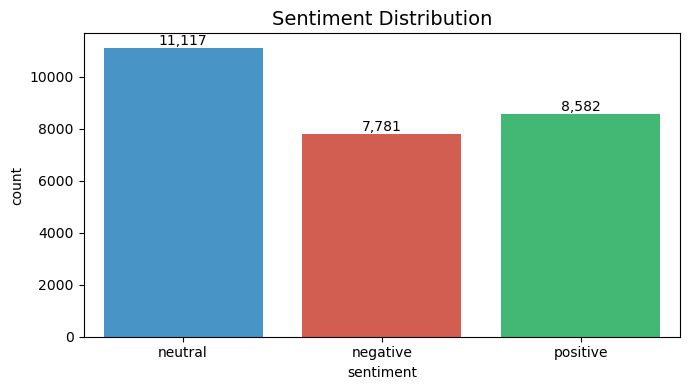

In [ ]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='sentiment',
                   palette={'positive':'#2ecc71','negative':'#e74c3c','neutral':'#3498db'})
plt.title('Sentiment Distribution', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('sentiment_dist.png', dpi=150)
plt.show()


## ☁️ Step 6: Word Clouds per Sentiment

Word clouds are a fun and intuitive way to see which words appear most
frequently in each category.

- **Positive tweets** → expect words like *love*, *amazing*, *great*
- **Negative tweets** → expect words like *terrible*, *worst*, *disappointed*
- **Neutral tweets** → expect more factual words like *available*, *includes*, *hours*

This helps us build an intuition for what patterns the model will learn.


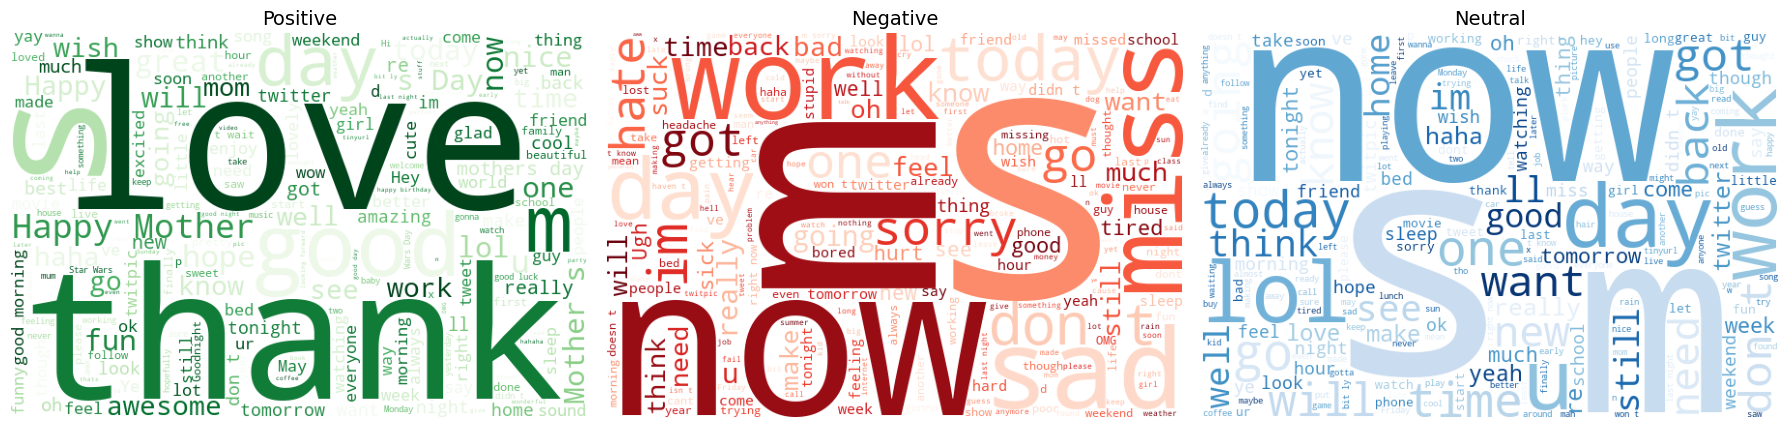

In [ ]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'positive':'Greens', 'negative':'Reds', 'neutral':'Blues'}

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    text = ' '.join(df[df['sentiment'] == sentiment]['text'].astype(str))
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=colors[sentiment]).generate(text)
    ax.imshow(wc)
    ax.axis('off')
    ax.set_title(sentiment.capitalize(), fontsize=14)

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()


## 🧹 Step 7: Preprocess / Clean the Text

Raw tweets are messy — they have URLs, @mentions, hashtags, numbers,
and punctuation that don't help our model learn anything useful.

So we write a `clean_text()` function that:
1. Lowercases everything
2. Removes URLs, mentions, and hashtags
3. Strips out punctuation and numbers
4. Removes **stopwords** (common words like *the*, *is*, *a* that carry no sentiment)

This is one of the most important steps — garbage in, garbage out!


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)           # remove mentions/hashtags
    text = re.sub(r'[^a-z\s]', '', text)            # remove punctuation/numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text', 'sentiment']].head(5)


,text,clean_text,sentiment
0,"I`d have responded, if I were going",responded going,neutral
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego,negative
2,my boss is bullying me...,boss bullying,negative
3,what interview! leave me alone,interview leave alone,negative
4,"Sons of ****, why couldn`t they put them on t...",sons couldnt put releases already bought,negative


## 📏 Step 8: How Long Are the Tweets?

Let's see if tweet length (word count) varies by sentiment.

Sometimes negative reviews tend to be longer (people rant more!)
and neutral ones shorter (just stating facts).

A box plot shows us the distribution of word counts per category —
including the median, spread, and any outliers.


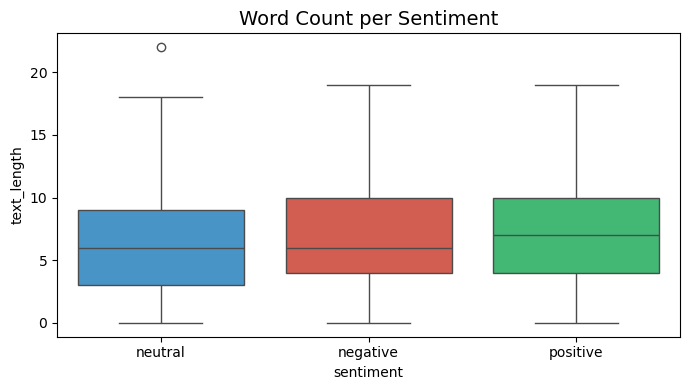

In [ ]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='sentiment', y='text_length',
            palette={'positive':'#2ecc71','negative':'#e74c3c','neutral':'#3498db'})
plt.title('Word Count per Sentiment', fontsize=14)
plt.tight_layout()
plt.show()


## ✂️ Step 9: Split Data & Convert Text to Numbers

Machine learning models can't read words — they need numbers.

**TF-IDF** (Term Frequency–Inverse Document Frequency) converts each tweet
into a numeric vector based on how important each word is.

We also split our data into:
- **80% training** → the model learns from this
- **20% testing** → we evaluate on data the model has never seen

We use `stratify=y` to make sure each sentiment is proportionally
represented in both splits.


In [ ]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Train size:", X_train_tfidf.shape)
print("Test size: ", X_test_tfidf.shape)


Train size: (21984, 10000)
Test size:  (5496, 10000)


## 🤖 Step 10: Train Three Different Models

Instead of committing to one model right away, let's try three and see
which performs best on our dataset:

1. **Logistic Regression** → simple, fast, and surprisingly powerful for text
2. **Naive Bayes** → classic text classification algorithm, very lightweight
3. **Linear SVM** → often the top performer for text classification tasks

We train all three and print their accuracy on the test set.
May the best model win! 🏆


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=2000)
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")


Logistic Regression: 0.6852
Naive Bayes: 0.6230
Linear SVM: 0.6678


## 📋 Step 11: Detailed Report of the Best Model

Accuracy alone doesn't tell the full story.

The **classification report** gives us:
- **Precision** → of all tweets predicted as positive, how many actually were?
- **Recall** → of all actual positive tweets, how many did we catch?
- **F1-Score** → a balance between precision and recall

We automatically pick whichever model scored highest in Cell 10
and print its full breakdown per sentiment class.


In [ ]:
best_name = max(results, key=results.get)
best_model = models[best_name]
y_pred = best_model.predict(X_test_tfidf)

print(f"Best Model: {best_name}  (Accuracy: {results[best_name]:.4f})\n")
print(classification_report(y_test, y_pred))


Best Model: Logistic Regression  (Accuracy: 0.6852)

              precision    recall  f1-score   support

    negative       0.72      0.60      0.66      1556
     neutral       0.62      0.74      0.68      2223
    positive       0.77      0.69      0.72      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.69      0.69      0.69      5496



## 🟦 Step 12: Confusion Matrix

A confusion matrix shows us exactly where the model is getting confused.

Each row = **actual** sentiment
Each column = **predicted** sentiment

The diagonal (top-left to bottom-right) = correct predictions ✅
Everything off-diagonal = mistakes ❌

This helps us spot patterns — like "is the model often confusing
neutral with positive?" — which guides future improvements.


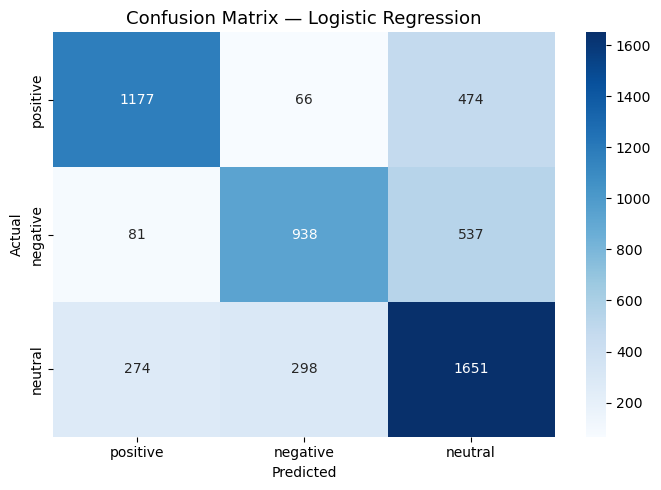

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=['positive','negative','neutral'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive','negative','neutral'],
            yticklabels=['positive','negative','neutral'])
plt.title(f'Confusion Matrix — {best_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


## 📈 Step 13: Compare All Models Visually

Let's put all three accuracy scores side-by-side in a bar chart
so we can clearly see which model won and by how much.

Sometimes the differences are tiny, sometimes dramatic — either way,
having a visual makes it much easier to communicate results.


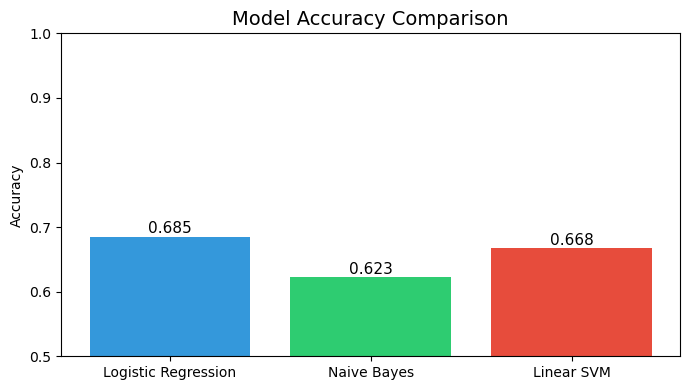

In [ ]:
plt.figure(figsize=(7, 4))
bars = plt.bar(results.keys(), results.values(), color=['#3498db','#2ecc71','#e74c3c'])
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
for bar, v in zip(bars, results.values()):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()


## 💾 Step 14: Save the Model & Vectorizer

Now that we have a trained model we're happy with, let's save it to disk.

We save **two files**:
- `sentiment_model.pkl` → the trained classifier
- `tfidf_vectorizer.pkl` → the fitted TF-IDF transformer

Why both? Because when we want to predict on new text, we first need
to transform it using the **same vectorizer** that was used during training.
We'll use these saved files in our Flask web app next!


In [ ]:
joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(tfidf,      'tfidf_vectorizer.pkl')
print("Model saved: sentiment_model.pkl")
print("Vectorizer saved: tfidf_vectorizer.pkl")


Model saved: sentiment_model.pkl
Vectorizer saved: tfidf_vectorizer.pkl


## 🎯 Step 15: Test It on Real Sentences

Let's do a quick sanity check — give the model some example sentences
and see if it predicts the right sentiment.

This is the moment of truth! We pass fresh text through:
1. The same `clean_text()` function we built earlier
2. The saved TF-IDF vectorizer
3. The trained model

If the predictions look sensible, our pipeline is working correctly
and we're ready to wrap it into a proper web app. 🚀


In [ ]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    return best_model.predict(vec)[0]

samples = [
    "I absolutely love this product, it is amazing!",
    "Terrible service, never coming back again.",
    "The store opens at 9am on weekdays."
]
for s in samples:
    print(f"  '{s}'\n  → {predict_sentiment(s).upper()}\n")


  'I absolutely love this product, it is amazing!'
  → POSITIVE

  'Terrible service, never coming back again.'
  → NEGATIVE

  'The store opens at 9am on weekdays.'
  → NEUTRAL

